# Local Polynomial Regression

## Learning Objectives
- Understand LPR as a generalization of LWLR — fit a degree-$d$ polynomial locally instead of a line
- Understand why degree $d = 1$ (LWLR) is biased near peaks and valleys, and how degree $d = 2$ corrects this
- Understand the polynomial basis expansion centered at the query point $x^*$
- Derive the weighted normal equation $\boldsymbol{\theta}^*(x^*) = (\Phi^\top W \Phi)^{-1} \Phi^\top W \mathbf{y}$
- Understand the derivative interpretation: $\theta_k = f^{(k)}(x^*) / k!$, so $2\theta_2 = f''(x^*)$ detects local curvature
- Implement `predict_lpr` and `predict_lpr_batch` in NumPy

## Problem Statement

Given a training set $\{(x^{(i)}, y^{(i)})\}_{i=1}^{m}$, predict $\hat{y}^*$ at a query point $x^*$ by fitting a **degree-$d$ polynomial** locally, weighting training examples by proximity to $x^*$.

---

### Why LWLR (Degree 1) Falls Short

LWLR fits a local **line** — a good approximation in linear regions but systematically biased wherever the true function curves. Near a local maximum, the fitted line must slope down on one side and up on the other; it cannot sit flat at the peak. The bias is proportional to $f''(x^*)$, the local curvature.

Fitting a local **quadratic** (degree 2) captures this curvature directly and eliminates the leading-order bias.

---

### Degree as a Hyperparameter

| Degree $d$ | Model fitted locally | Also known as | Captures |
|---|---|---|---|
| 0 | Constant $\theta_0$ | Nadaraya-Watson | Level only |
| 1 | Line $\theta_0 + \theta_1 u$ | LWLR | Level + slope |
| 2 | Quadratic $\theta_0 + \theta_1 u + \theta_2 u^2$ | LOESS (default) | Level + slope + curvature |
| $d$ | Degree-$d$ polynomial | LPR | $d$-th order Taylor approximation |

where $u = x - x^*$ denotes the centered coordinate.

---

### Core Idea

Expand each training input around $x^*$, fit a polynomial in the centered coordinate $u^{(i)} = x^{(i)} - x^*$ using weighted least squares, and read off $\theta_0$ as the prediction. The higher-order coefficients give derivative estimates at $x^*$:

$\displaystyle \theta_k = \frac{f^{(k)}(x^*)}{k!}$

In particular, $2\theta_2 = f''(x^*)$: positive means local minimum, negative means local maximum.

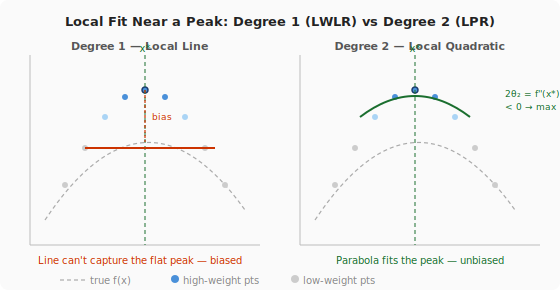

In [1]:
from IPython.display import SVG, display

svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="560" height="290" viewBox="0 0 560 290">
  <rect width="560" height="290" fill="#fafafa" rx="8"/>
  <text x="280" y="26" text-anchor="middle" font-size="13" font-weight="bold" fill="#222">Local Fit Near a Peak: Degree 1 (LWLR) vs Degree 2 (LPR)</text>

  <!-- LEFT: degree-1 local fit at peak -->
  <text x="140" y="50" text-anchor="middle" font-size="11" font-weight="bold" fill="#555">Degree 1 — Local Line</text>
  <line x1="30" y1="245" x2="260" y2="245" stroke="#bbb" stroke-width="1"/>
  <line x1="30" y1="55"  x2="30"  y2="245" stroke="#bbb" stroke-width="1"/>

  <!-- True curve (parabola opening down, peak at x=145) -->
  <path d="M 45,220 Q 145,70 245,210" fill="none" stroke="#aaa" stroke-width="1.2" stroke-dasharray="4,3"/>

  <!-- Data points on the curve -->
  <circle cx="65"  cy="185" r="3" fill="#ccc"/>
  <circle cx="85"  cy="148" r="3" fill="#ccc"/>
  <circle cx="105" cy="117" r="3" fill="#aad4f5"/>
  <circle cx="125" cy="97"  r="3" fill="#4a90d9"/>
  <circle cx="145" cy="90"  r="3" fill="#4a90d9" stroke="#1a3a6e" stroke-width="1.5"/>
  <circle cx="165" cy="97"  r="3" fill="#4a90d9"/>
  <circle cx="185" cy="117" r="3" fill="#aad4f5"/>
  <circle cx="205" cy="148" r="3" fill="#ccc"/>
  <circle cx="225" cy="185" r="3" fill="#ccc"/>

  <!-- Query point vertical line -->
  <line x1="145" y1="55" x2="145" y2="245" stroke="#1a6e2e" stroke-width="1" stroke-dasharray="4,3"/>
  <text x="145" y="52" text-anchor="middle" font-size="10" fill="#1a6e2e">x*</text>

  <!-- Degree-1 local fit: line through weighted points - must slope, misses the peak -->
  <line x1="85" y1="148" x2="215" y2="148" stroke="#cc3300" stroke-width="2"/>

  <!-- Bias arrow: gap between line and true peak -->
  <line x1="145" y1="90" x2="145" y2="142" stroke="#cc3300" stroke-width="1.2" stroke-dasharray="3,2"/>
  <text x="152" y="120" font-size="9" fill="#cc3300">bias</text>

  <text x="140" y="264" text-anchor="middle" font-size="10" fill="#cc3300">Line can't capture the flat peak — biased</text>

  <!-- RIGHT: degree-2 local fit at peak -->
  <text x="420" y="50" text-anchor="middle" font-size="11" font-weight="bold" fill="#555">Degree 2 — Local Quadratic</text>
  <line x1="300" y1="245" x2="540" y2="245" stroke="#bbb" stroke-width="1"/>
  <line x1="300" y1="55"  x2="300" y2="245" stroke="#bbb" stroke-width="1"/>

  <!-- True curve -->
  <path d="M 315,220 Q 415,70 515,210" fill="none" stroke="#aaa" stroke-width="1.2" stroke-dasharray="4,3"/>

  <!-- Data points -->
  <circle cx="335" cy="185" r="3" fill="#ccc"/>
  <circle cx="355" cy="148" r="3" fill="#ccc"/>
  <circle cx="375" cy="117" r="3" fill="#aad4f5"/>
  <circle cx="395" cy="97"  r="3" fill="#4a90d9"/>
  <circle cx="415" cy="90"  r="3" fill="#4a90d9" stroke="#1a3a6e" stroke-width="1.5"/>
  <circle cx="435" cy="97"  r="3" fill="#4a90d9"/>
  <circle cx="455" cy="117" r="3" fill="#aad4f5"/>
  <circle cx="475" cy="148" r="3" fill="#ccc"/>
  <circle cx="495" cy="185" r="3" fill="#ccc"/>

  <!-- Query point vertical line -->
  <line x1="415" y1="55" x2="415" y2="245" stroke="#1a6e2e" stroke-width="1" stroke-dasharray="4,3"/>
  <text x="415" y="52" text-anchor="middle" font-size="10" fill="#1a6e2e">x*</text>

  <!-- Degree-2 local fit: parabola matching the true curve at peak -->
  <path d="M 360,117 Q 415,75 470,117" fill="none" stroke="#1a6e2e" stroke-width="2"/>

  <!-- 2*theta_2 label -->
  <text x="505" y="97"  font-size="9" fill="#1a6e2e">2&#x03B8;&#x2082; = f''(x*)</text>
  <text x="505" y="110" font-size="9" fill="#1a6e2e">&lt; 0 &#x2192; max</text>

  <text x="420" y="264" text-anchor="middle" font-size="10" fill="#1a6e2e">Parabola fits the peak — unbiased</text>

  <!-- Legend for both panels -->
  <line x1="60" y1="280" x2="85" y2="280" stroke="#aaa" stroke-width="1.2" stroke-dasharray="4,3"/>
  <text x="90" y="284" font-size="10" fill="#888">true f(x)</text>
  <circle cx="175" cy="279" r="4" fill="#4a90d9"/>
  <text x="183" y="284" font-size="10" fill="#888">high-weight pts</text>
  <circle cx="295" cy="279" r="4" fill="#ccc"/>
  <text x="303" y="284" font-size="10" fill="#888">low-weight pts</text>
</svg>
"""

display(SVG(svg))

## Hypothesis Function

For a scalar query point $x^* \in \mathbb{R}$, define the **centered coordinate** $u^{(i)} = x^{(i)} - x^*$ and the **polynomial basis vector** of degree $d$:

$\displaystyle \phi(x^{(i)}; x^*) = \begin{bmatrix} 1 \\ u^{(i)} \\ (u^{(i)})^2 \\ \vdots \\ (u^{(i)})^d \end{bmatrix} \in \mathbb{R}^{d+1}$

Stack all $m$ examples into the **local design matrix**:

$\displaystyle \Phi(x^*) = \begin{bmatrix} \phi(x^{(1)}; x^*)^\top \\ \phi(x^{(2)}; x^*)^\top \\ \vdots \\ \phi(x^{(m)}; x^*)^\top \end{bmatrix} \in \mathbb{R}^{m \times (d+1)}$

The prediction at $x^*$ is the intercept of the locally fitted polynomial:

$\displaystyle \hat{y}^* = \theta_0^*(x^*)$

because $\phi(x^*; x^*) = [1, 0, 0, \ldots, 0]^\top$ — all centered terms vanish at the query point itself.

**Note**: for $d = 1$ this reduces to LWLR with $\Phi = [1, u]$; for $d = 0$ it reduces to Nadaraya-Watson kernel regression.

## Derivation

**High-level steps:**
1. Define the locally weighted polynomial cost $J(\boldsymbol{\theta}; x^*)$
2. Write in matrix form using $\Phi(x^*)$ and weight matrix $W$
3. Compute the gradient $\nabla_{\boldsymbol{\theta}} J$
4. Set to zero and solve — identical in structure to LWLR, with $\Phi$ replacing $X$
5. Interpret the coefficients as scaled derivatives of $f$ at $x^*$

---

**Step 1 — Weighted polynomial cost**

$\displaystyle J(\boldsymbol{\theta}; x^*) = \sum_{i=1}^{m} w_i \left(\sum_{k=0}^{d} \theta_k (u^{(i)})^k - y^{(i)}\right)^2$

where $u^{(i)} = x^{(i)} - x^*$ and $w_i = \exp\!\left(-\dfrac{(x^{(i)} - x^*)^2}{2\tau^2}\right)$.

---

**Step 2 — Matrix form**

$\displaystyle J(\boldsymbol{\theta}; x^*) = (\Phi\boldsymbol{\theta} - \mathbf{y})^\top W (\Phi\boldsymbol{\theta} - \mathbf{y})$

with $W = \mathrm{diag}(w_1, \ldots, w_m)$.

---

**Step 3 — Gradient**

$\displaystyle \nabla_{\boldsymbol{\theta}} J = 2\,\Phi^\top W (\Phi\boldsymbol{\theta} - \mathbf{y})$

---

**Step 4 — Weighted Normal Equation**

Setting the gradient to zero:

$\displaystyle \Phi^\top W \Phi\,\boldsymbol{\theta} = \Phi^\top W \mathbf{y}$

$\displaystyle \boldsymbol{\theta}^*(x^*) = (\Phi^\top W \Phi)^{-1} \Phi^\top W \mathbf{y}$

This is structurally identical to the LWLR weighted normal equation — the only change is $X \to \Phi(x^*)$.

---

**Step 5 — Derivative interpretation (Taylor expansion)**

By Taylor's theorem, for smooth $f$:

$\displaystyle f(x) = f(x^*) + f'(x^*)(x - x^*) + \frac{f''(x^*)}{2}(x - x^*)^2 + \cdots$

Matching terms with $\theta_0 + \theta_1 u + \theta_2 u^2 + \cdots$:

$\displaystyle \theta_k^*(x^*) = \frac{f^{(k)}(x^*)}{k!}$

In particular:

$\displaystyle \theta_1^* = f'(x^*) \quad \text{(local slope)}$

$\displaystyle 2\theta_2^* = f''(x^*) \begin{cases} > 0 & \text{local minimum} \\ < 0 & \text{local maximum} \\ = 0 & \text{inflection or linear region} \end{cases}$

## Prediction Algorithm

LPR is a **lazy learner** — no offline training. All computation happens per query point.

**Step 1 — For each query point $x^*$, compute centered coordinates**

$\displaystyle u^{(i)} = x^{(i)} - x^*, \quad i = 1, \ldots, m$

**Step 2 — Build the local polynomial design matrix**

$\displaystyle \Phi(x^*) = \begin{bmatrix} 1 & u^{(1)} & (u^{(1)})^2 & \cdots & (u^{(1)})^d \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & u^{(m)} & (u^{(m)})^2 & \cdots & (u^{(m)})^d \end{bmatrix} \in \mathbb{R}^{m \times (d+1)}$

**Step 3 — Compute Gaussian kernel weights**

$\displaystyle w_i = \exp\!\left(-\frac{(u^{(i)})^2}{2\tau^2}\right), \qquad W = \mathrm{diag}(w_1, \ldots, w_m)$

**Step 4 — Solve the weighted normal equation**

$\displaystyle \boldsymbol{\theta}^* = (\Phi^\top W \Phi)^{-1} \Phi^\top W \mathbf{y}$

Use `np.linalg.solve` for stability.

**Step 5 — Return prediction and derivative estimates**

$\displaystyle \hat{y}^* = \theta_0^*, \qquad \hat{f}'(x^*) = \theta_1^*, \qquad \hat{f}''(x^*) = 2\theta_2^*$

**Complexity**: $O(md^2 + d^3)$ per query point — building $\Phi$ costs $O(md)$, solving the $(d+1) \times (d+1)$ system costs $O(d^3)$. For small fixed $d$, cost is dominated by the $O(m)$ weight computation.

## Key Properties

**Generalizes LWLR** — LPR with $d = 1$ and Gaussian kernel is identical to LWLR. LPR with $d = 0$ is Nadaraya-Watson kernel regression.

**Bias reduction** — LWLR has bias $O(\tau^2 f''(x^*))$ near curves. Each additional degree eliminates one order of bias. Degree $d$ gives bias $O(\tau^{d+1})$.

**Derivative estimation** — the fitted coefficients are estimators of scaled derivatives: $\theta_k^* \approx f^{(k)}(x^*) / k!$. This makes LPR useful for gradient and curvature estimation, not just prediction.

**LOESS** (Locally Estimated Scatterplot Smoothing) is LPR with:
- degree $d = 2$ (default in `statsmodels`, R's `loess`)
- tricube kernel $w_i = \bigl(1 - |u_i/h|^3\bigr)^3 \cdot \mathbf{1}[|u_i| < h]$ (compact support, bounded window)
- iterative re-weighting to downweight outliers (robust LOESS)

**Boundary behavior** — LPR of degree $d \geq 1$ does not suffer from boundary bias (the kernel boundary effect that plagues degree-0 Nadaraya-Watson), because the polynomial absorbs the asymmetry.

**Bandwidth $\tau$** — same bias-variance tradeoff as LWLR: small $\tau$ = high variance, large $\tau$ = high bias. Chosen by cross-validation. For fixed $d$, optimal $\tau \propto m^{-1/(2d+3)}$ (minimax rate).

In [2]:
import numpy as np

def predict_lpr(X, y, x_query, tau=1.0, degree=2):
    """
    Inputs
    ------
    X       : np.ndarray, shape (m,)   — scalar training inputs (1D)
    y       : np.ndarray, shape (m,)   — target values
    x_query : float                    — scalar query point
    tau     : float                    — bandwidth; controls how quickly weights decay with distance
    degree  : int                      — polynomial degree d (1 = LWLR, 2 = LOESS-style)

    Output
    ------
    y_hat   : float                    — predicted value at x_query (= theta_0)
    theta   : np.ndarray, shape (d+1,) — fitted coefficients; theta[k] ≈ f^(k)(x_query) / k!
                                         so 2*theta[2] ≈ f''(x_query): >0 min, <0 max
    """
    u = X - x_query                                          # centered coordinates (m,)
    Phi = np.column_stack([u ** k for k in range(degree + 1)])  # (m, d+1)
    w = np.exp(-(u ** 2) / (2 * tau ** 2))                  # Gaussian kernel weights (m,)
    W = np.diag(w)
    theta = np.linalg.solve(Phi.T @ W @ Phi, Phi.T @ W @ y)
    return theta[0], theta


def predict_lpr_batch(X, y, X_query, tau=1.0, degree=2):
    """
    Inputs
    ------
    X       : np.ndarray, shape (m,)   — scalar training inputs
    y       : np.ndarray, shape (m,)   — target values
    X_query : np.ndarray, shape (p,)   — p scalar query points
    tau     : float                    — bandwidth parameter
    degree  : int                      — polynomial degree

    Output
    ------
    y_hat   : np.ndarray, shape (p,)      — predicted value at each query point
    thetas  : np.ndarray, shape (p, d+1)  — fitted coefficients at each query point
    """
    results = [predict_lpr(X, y, xq, tau, degree) for xq in X_query]
    y_hat  = np.array([r[0] for r in results])
    thetas = np.array([r[1] for r in results])
    return y_hat, thetas